# Analisi delle immagini, riscritto in grazia

## Importazione delle librerie



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets

In [2]:
%matplotlib widget
plt.close('all')

## Funzioni utili

### Caricamento e conversione dati

In [3]:
# conversione dei timestamp nello stesso formato tra bilancia e immagini (sarebbe il caso di sistemarlo anche nell'interfaccia...)

FORMATO_COMUNE = "%Y-%m-%d %H:%M:%S"

def bilancia_timestamp_to_common(timestamp_unix, fmt=FORMATO_COMUNE):
    """
    Timestamp bilancia (Unix epoch) -> formato comune.
    Supporta secondi (10 cifre) e millisecondi (13 cifre).
    """
    ts = float(timestamp_unix)
    if ts > 1e12:  # millisecondi
        ts /= 1000.0
    return time.strftime(fmt, time.localtime(ts))


def image_timestamp_to_common(image_name_or_timestamp, fmt=FORMATO_COMUNE):
    """
    Timestamp immagini -> formato comune.
    Accetta:
    - 'frame_YYYYMMDD_HHMMSS.png'
    - 'YYYYMMDD_HHMMSS'
    - 'YYYY-MM-DD_HH-MM-SS' (nome cartella sessione)
    """
    s = str(image_name_or_timestamp)
    base = os.path.basename(s)

    m1 = re.search(r"(\d{8}_\d{6})", base)
    if m1:
        t = time.strptime(m1.group(1), "%Y%m%d_%H%M%S")
        return time.strftime(fmt, t)

    m2 = re.search(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", base)
    if m2:
        t = time.strptime(m2.group(1), "%Y-%m-%d_%H-%M-%S")
        return time.strftime(fmt, t)

    raise ValueError("Formato timestamp immagine non riconosciuto")

In [4]:
# caricamento dati dalle immagini

base_img_folder = "data/raw"

def load_images_from_folder(folder):
    """
    Carica tutte le immagini PNG da una cartella, restituendo una lista di immagini e i loro timestamp in formato comune.
    """
    images = []
    timestamps = []
    for filename in os.listdir(folder):
        if filename.endswith(".png"):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                images.append(img)
                timestamps.append(image_timestamp_to_common(filename))
    return images, timestamps

def load_images_from_folders(folders):
    """
    Carica immagini da più cartelle, restituendo liste aggregate di immagini e timestamp.
    """
    all_images = []
    all_timestamps = []
    for folder in folders:
        images, timestamps = load_images_from_folder(folder)
        all_images.extend(images)
        all_timestamps.extend(timestamps)
    return all_images, all_timestamps

def sort_images_and_timestamps(images, timestamps):
    """
    Ordina immagini e timestamp in base ai timestamp.
    """
    combined = list(zip(timestamps, images))
    combined.sort(key=lambda x: x[0])
    sorted_timestamps, sorted_images = zip(*combined)
    return list(sorted_images), list(sorted_timestamps)


In [5]:
# carica timestamp, rate, thickness dalla bilancia

def load_bilancia_data(file_path):
    """
    Carica dati dalla bilancia, restituendo liste di timestamp (formato comune), rate e thickness.
    """
    timestamps = []
    rates = []
    thicknesses = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                ts_common = bilancia_timestamp_to_common(parts[0])
                timestamps.append(ts_common)
                rates.append(float(parts[1]))
                thicknesses.append(float(parts[2]))
    return timestamps, rates, thicknesses

In [6]:
def extract_common_timestamp_points(image_timestamps, bilancia_timestamps, max_diff_seconds=1.0):
    """
    Trova timestamp comuni tra immagini e bilancia, restituendo indici corrispondenti.
    """
    common_image_indices = []
    common_bilancia_indices = []
    
    for i, img_ts in enumerate(image_timestamps):
        img_time = time.strptime(img_ts, FORMATO_COMUNE)
        img_seconds = time.mktime(img_time)
        
        for j, bil_ts in enumerate(bilancia_timestamps):
            bil_time = time.strptime(bil_ts, FORMATO_COMUNE)
            bil_seconds = time.mktime(bil_time)
            
            if abs(img_seconds - bil_seconds) <= max_diff_seconds:
                common_image_indices.append(i)
                common_bilancia_indices.append(j)
                break  # Assumiamo un match unico per ogni immagine
    
    return common_image_indices, common_bilancia_indices

def interpolate_timestamps(image_timestamps, bilancia_timestamps, bilancia_values):
    """
    Interpola i valori della bilancia per i timestamp delle immagini.
    Restituisce una lista di valori interpolati corrispondenti ai timestamp delle immagini.
    """
    image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
    bilancia_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in bilancia_timestamps]
    
    interpolated_values = np.interp(image_seconds, bilancia_seconds, bilancia_values)
    return interpolated_values


### Elaborazione immagini

In [7]:
def moving_average_images(images, window_size):
    """
    Applica una media mobile alle immagini, restituendo una nuova lista di immagini filtrate.
    """

    if window_size == 1:
        return images  # nessun filtro se la finestra è 1

    moving_avg_imgs = []

    for i in range(len(images)):
        start_idx = max(0, i - window_size//2 + 1)
        end_idx = min(len(images), i + window_size//2 + 1)
        window_imgs = images[start_idx:end_idx]
        moving_avg_img = np.mean(window_imgs, axis=0).astype(np.uint8)
        moving_avg_imgs.append(moving_avg_img)

    return moving_avg_imgs

def extract_roi_from_images(images, roi_center, roi_radius):
    """
    Estrae una regione di interesse (ROI) circolare da ogni immagine, restituendo una lista di immagini ROI.
    """
    roi_images = []

    for img in images:
        mask = np.zeros_like(img, dtype=np.uint8)
        cv2.circle(mask, roi_center, roi_radius, 255, -1)
        roi_img = cv2.bitwise_and(img, img, mask=mask)
        roi_images.append(roi_img)

    return roi_images

def compute_difference_from_reference(images, reference_image):
    """
    Calcola la differenza assoluta tra ogni immagine e un'immagine di riferimento, restituendo una lista di immagini differenza.
    """
    difference_images = []

    for img in images:
        diff_img = cv2.absdiff(img, reference_image)
        difference_images.append(diff_img)

    return difference_images

def compute_average_intensity(images):
    """
    Calcola l'intensità media di ogni immagine, restituendo una lista di valori di intensità media.
    """
    avg_intensities = []

    for img in images:
        avg_intensity = np.mean(img)
        avg_intensities.append(avg_intensity)

    return avg_intensities

def extract_line_profile(images, x0, y0, x1, y1):
    """
    Estrae il profilo di intensità lungo una linea definita da (x0, y0) a (x1, y1) per ogni immagine, restituendo una lista di array di profili.
    """
    line_profiles = []

    for img in images:
        line_profile = cv2.line(img.copy(), (x0, y0), (x1, y1), 255, 1)
        line_profiles.append(line_profile)

    return line_profiles

def extract_line_profiles_circle(images, center, radius, num_profiles=10):
    """
    Estrae i line profile lungo diametri di una circonferenza definita da un centro e un raggio, restituendo una lista di array di profili.
    """

    line_profiles = []
    angles = np.linspace(0, 2 * np.pi, num_profiles, endpoint=False)

    for img in images:
        profiles_for_image = []
        for angle in angles:
            x0 = int(center[0] + radius * np.cos(angle))
            y0 = int(center[1] + radius * np.sin(angle))
            x1 = int(center[0] - radius * np.cos(angle))
            y1 = int(center[1] - radius * np.sin(angle))
            line_profile = cv2.line(img.copy(), (x0, y0), (x1, y1), 255, 1)
            profiles_for_image.append(line_profile)
        line_profiles.append(profiles_for_image)

    return line_profiles


In [8]:
class RoiSelectorWidget:
    def __init__(self, image):
        self.image = image
        self.roi_center = (image.shape[1] // 2, image.shape[0] // 2)
        self.roi_radius = min(image.shape) // 4

        with plt.ioff():
            self.fig, self.ax = plt.subplots()
            self.ax.imshow(image, cmap='gray')
            self.circle = plt.Circle(self.roi_center, self.roi_radius, color='r', fill=False)
            self.ax.add_patch(self.circle)
            self.ax.set_title("Clicca con sinistro per spostare, destro per ridimensionare")

        self.cid_click = self.fig.canvas.mpl_connect('button_press_event', self.on_click)

    def on_click(self, event):
        # se tasto sinistro, cambia il centro
        if event.button == 1:
            self.roi_center = (int(event.xdata), int(event.ydata))
            self.update_circle()
        
        # se tasto destro, cambia il raggio
        elif event.button == 3:
            dx = event.xdata - self.roi_center[0]
            dy = event.ydata - self.roi_center[1]
            self.roi_radius = int(sqrt(dx**2 + dy**2))
            self.update_circle()

    def update_circle(self):
        self.circle.center = self.roi_center
        self.circle.radius = self.roi_radius
        self.fig.canvas.draw()
    
    def draw(self):
        self.fig.show()
    
    @property
    def roi(self):
        return self.roi_center, self.roi_radius

## Test e visualizzazione

In [19]:
folder_selector = widgets.Dropdown(
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))]),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('2026-04-27_10-19-49', '2026-04-27_17-34-45', '2026-04-29_18-06-55'…

In [ ]:
data_folder = os.path.join(base_img_folder, folder_selector.value)
image_folder = os.path.join(data_folder, "images")
bilancia_file = os.path.join(data_folder, "data", "points.txt")

try: 
    images, image_timestamps = load_images_from_folder(image_folder)
    images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

    bilancia_timestamps, bilancia_rates, bilancia_thicknesses = load_bilancia_data(bilancia_file)

except Exception as e:
    print(f"Errore caricamento dati: {e}")
    images, image_timestamps = [], []
    bilancia_timestamps, bilancia_rates, bilancia_thicknesses = [], [], []

data/raw/2026-04-29_18-37-09/images


In [9]:
image_folder = os.path.join(base_img_folder, "2026-04-27_17-36-39/images/")

images, image_timestamps = load_images_from_folder(image_folder)
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

ref_img = np.mean(images[:10], axis=0).astype(np.uint8)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/2026-04-27_17-36-39/images/'

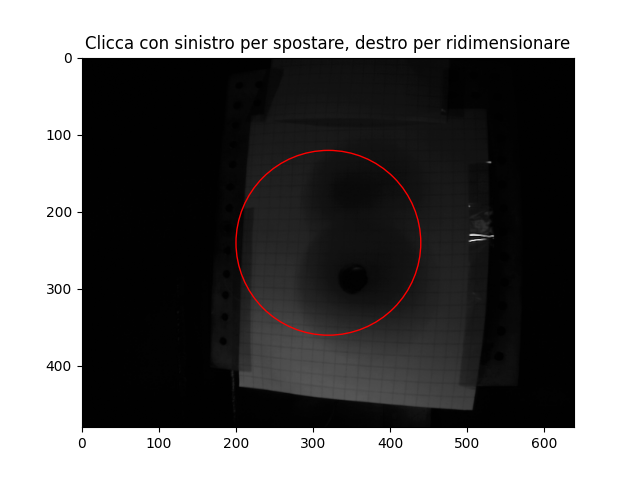

In [ ]:
roi_selector = RoiSelectorWidget(ref_img)
roi_selector.draw()

In [ ]:
roi_center, roi_radius = roi_selector.roi

roi_imgs = extract_roi_from_images(images, roi_center, roi_radius)
roi_ref = extract_roi_from_images([ref_img], roi_center, roi_radius)[0]
img_diffs = compute_difference_from_reference(roi_imgs, roi_ref)

In [ ]:
bilancia_path = "data/raw/2026-04-27_17-36-39/data/points.txt"
dati_bilancia = load_bilancia_data(bilancia_path)
bilancia_timestamps, rates, thicknesses = dati_bilancia



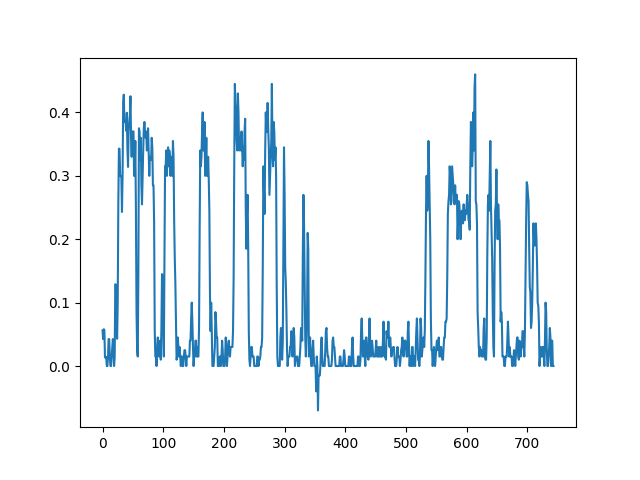

In [ ]:
plt.figure()
rates = np.gradient(thicknesses)
plt.plot(rates)

plt.show()

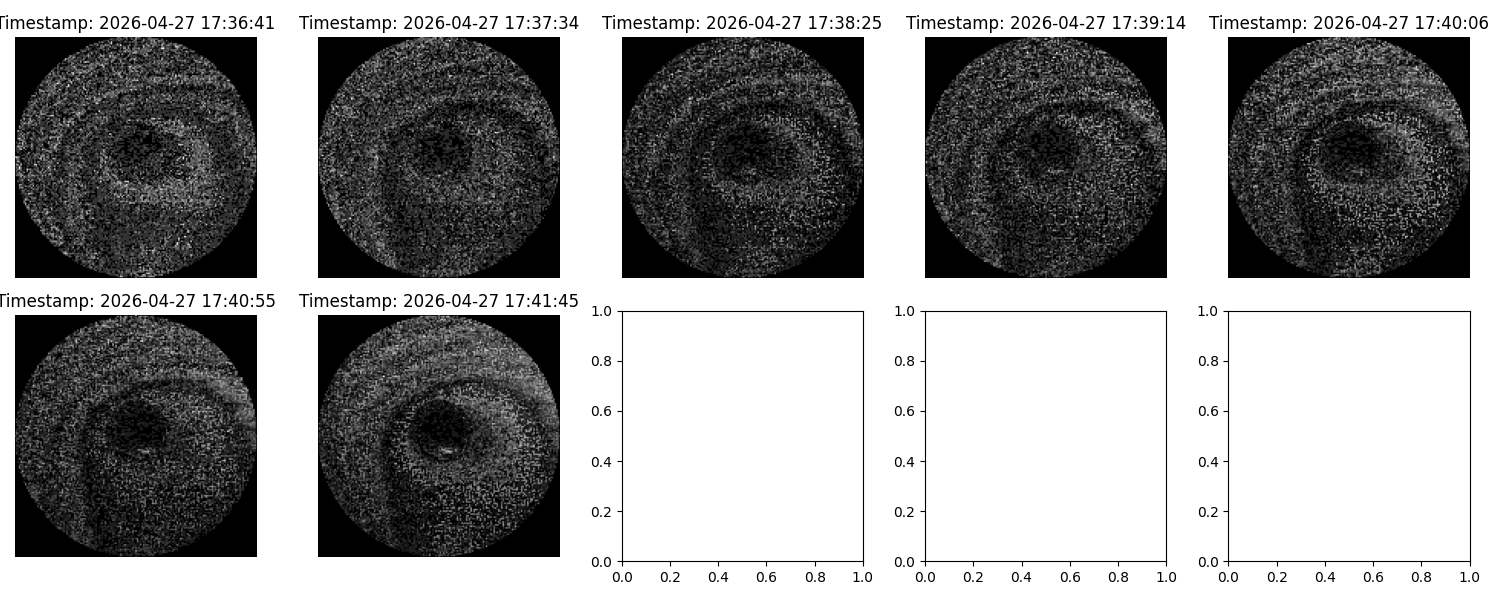

In [ ]:
# mostra ogni step immagini
step = 30
reduced_img_num = (len(img_diffs) + step - 1) // step
ncols = 5
nrows = (reduced_img_num + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
for i in range(0, len(img_diffs), step):
    img = img_diffs[i]
    ts = image_timestamps[i]
    row = (i // step) // ncols
    col = (i // step) % ncols
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f"Timestamp: {ts}")
    axes[row, col].axis('off')
    axes[row, col].set_aspect('equal')
    axes[row, col].set_xlim(roi_center[0] - roi_radius, roi_center[0] + roi_radius)
    axes[row, col].set_ylim(roi_center[1] - roi_radius, roi_center[1] + roi_radius)
plt.tight_layout()
plt.show()

In [ ]:
# converti i timetsmp in secondi
image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
bilancia_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in bilancia_timestamps]

print("Timestamp immagini (secondi):", image_seconds)
print("Timestamp bilancia (secondi):", bilancia_seconds)

max_t = min(image_seconds[-1], bilancia_seconds[-1])

# tieni solo i punti prima di max_t
image_seconds = [t for t in image_seconds if t <= max_t]
bilancia_seconds = [t for t in bilancia_seconds if t <= max_t]
rates = rates[:len(bilancia_seconds)]
thicknesses = thicknesses[:len(bilancia_seconds)]
img_diffs = img_diffs[:len(image_seconds)]

Timestamp immagini (secondi): [1777304201.0, 1777304203.0, 1777304205.0, 1777304206.0, 1777304208.0, 1777304210.0, 1777304211.0, 1777304213.0, 1777304215.0, 1777304216.0, 1777304218.0, 1777304220.0, 1777304222.0, 1777304223.0, 1777304225.0, 1777304226.0, 1777304228.0, 1777304230.0, 1777304232.0, 1777304234.0, 1777304236.0, 1777304238.0, 1777304240.0, 1777304242.0, 1777304243.0, 1777304246.0, 1777304247.0, 1777304249.0, 1777304251.0, 1777304252.0, 1777304254.0, 1777304255.0, 1777304257.0, 1777304259.0, 1777304261.0, 1777304263.0, 1777304264.0, 1777304266.0, 1777304268.0, 1777304269.0, 1777304271.0, 1777304273.0, 1777304274.0, 1777304276.0, 1777304277.0, 1777304279.0, 1777304281.0, 1777304283.0, 1777304284.0, 1777304286.0, 1777304288.0, 1777304290.0, 1777304291.0, 1777304292.0, 1777304294.0, 1777304296.0, 1777304298.0, 1777304300.0, 1777304301.0, 1777304303.0, 1777304305.0, 1777304307.0, 1777304309.0, 1777304310.0, 1777304312.0, 1777304314.0, 1777304315.0, 1777304316.0, 1777304318.0, 177

-1.143076923076923 1.140004135649297


c:\Users\miriam.cassella\Desktop\lab_materia_2\.conda\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\miriam.cassella\Desktop\lab_materia_2\.conda\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


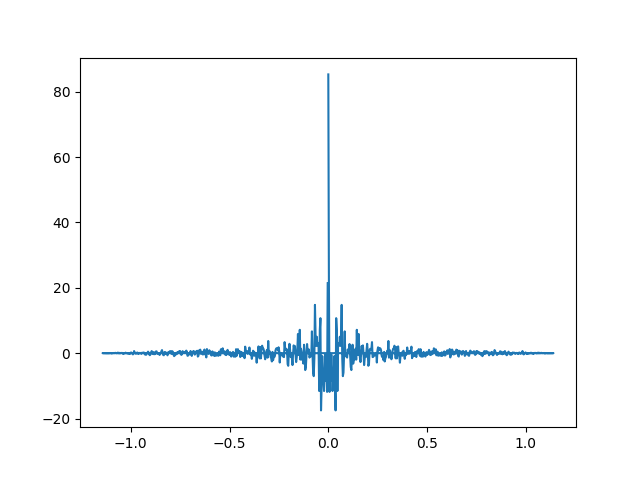

In [ ]:
diff_bilancia_seconds = np.diff(bilancia_seconds)
mean_delta_t = np.mean(diff_bilancia_seconds)
#print(mean_delta_t)
fs =1/mean_delta_t

fft = np.fft.fft(rates)
freqs = np.fft.fftfreq(len(rates), mean_delta_t)
plt.figure()
plt.plot(freqs, fft)

print(min(freqs),max(freqs))

plt.show()


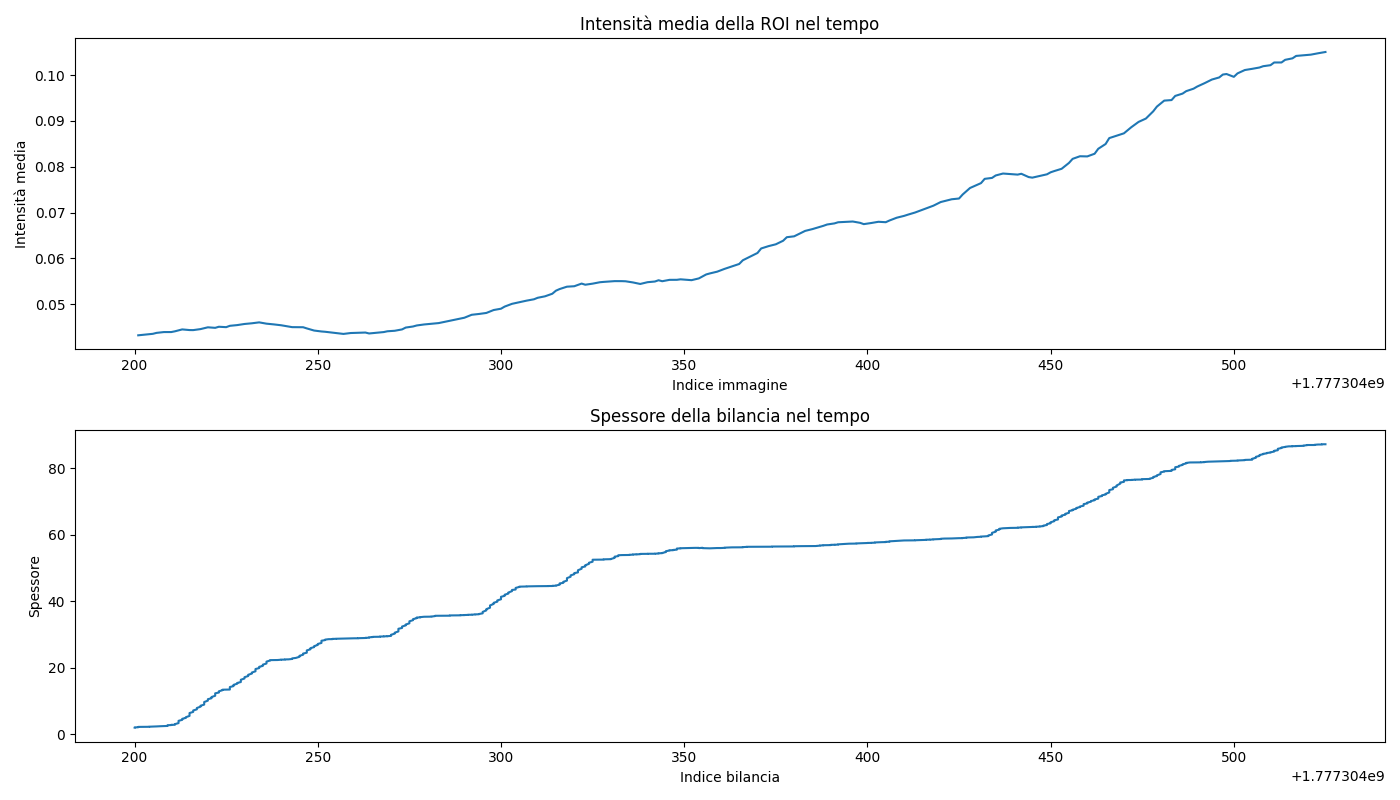

In [ ]:
avg_img_diffs = moving_average_images(img_diffs, window_size=20)
means = compute_average_intensity(avg_img_diffs)

plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
ax = plt.gca()
plt.plot(image_seconds, means, label='Intensità media ROI')
plt.xlabel('Indice immagine')
plt.ylabel('Intensità media')
plt.title('Intensità media della ROI nel tempo')

plt.subplot(2, 1, 2, sharex=ax)
plt.plot(bilancia_seconds, thicknesses, label='Spessore')
plt.xlabel('Indice bilancia')
plt.ylabel('Spessore')
plt.title('Spessore della bilancia nel tempo')

plt.tight_layout()
plt.show()

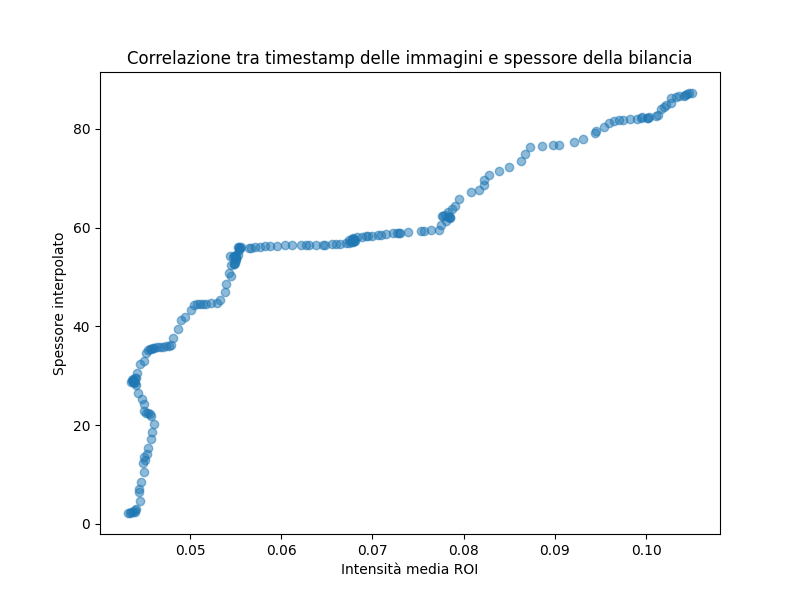

In [ ]:
# interpolazione dei valori della bilancia per i timestamp delle immagini
interpolated_thicknesses = interpolate_timestamps(image_timestamps[:len(image_seconds)], bilancia_timestamps[:len(bilancia_seconds)], thicknesses)

# scatter plot per correlazione
plt.figure(figsize=(8, 6))

plt.scatter(means, interpolated_thicknesses, alpha=0.5)
plt.xlabel('Intensità media ROI')
plt.ylabel('Spessore interpolato')
plt.title('Correlazione tra timestamp delle immagini e spessore della bilancia')
plt.show()


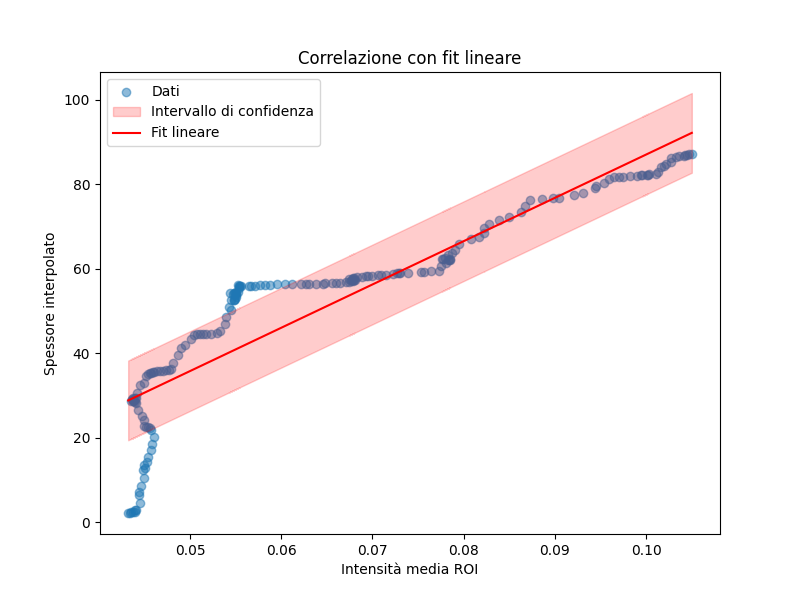

In [ ]:
# regressione lineare
m, residuals, rank, s, rcond = np.polyfit(means, interpolated_thicknesses, deg=1, full=True)

std_dev = sqrt(residuals[0] / (len(means) - 2))

min_conf_interval = m[0] * np.array(means) + m[1] - std_dev
max_conf_interval = m[0] * np.array(means) + m[1] + std_dev

plt.figure(figsize=(8, 6))

plt.scatter(means, interpolated_thicknesses, alpha=0.5, label='Dati')
plt.fill_between(means, min_conf_interval, max_conf_interval, color='red', alpha=0.2, label='Intervallo di confidenza')
plt.plot(means, m[0] * np.array(means) + m[1], color='red', label='Fit lineare')

plt.xlabel('Intensità media ROI')
plt.ylabel('Spessore interpolato')
plt.title('Correlazione con fit lineare')
plt.legend()
plt.show()

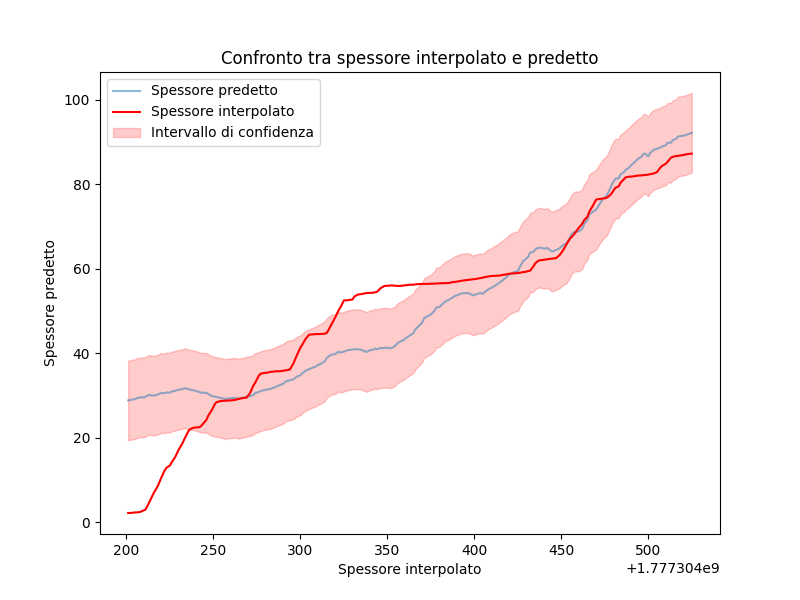

In [ ]:
# confronto predizione vs dati reali
predicted_thicknesses = m[0] * np.array(means) + m[1]

plt.figure(figsize=(8, 6))

plt.plot(image_seconds, predicted_thicknesses, alpha=0.5, label='Spessore predetto')

plt.plot(image_seconds, interpolated_thicknesses, color='red', label='Spessore interpolato')

plt.fill_between(image_seconds, min_conf_interval, max_conf_interval, color='red', alpha=0.2, label='Intervallo di confidenza')

plt.xlabel('Spessore interpolato')
plt.ylabel('Spessore predetto')
plt.title('Confronto tra spessore interpolato e predetto')
plt.legend()
plt.show()